<a href="https://colab.research.google.com/github/Sruthi-Gudelli/Plant-Disease-Detection-Treatment-Recommendation/blob/main/Baseline_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary libraries

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

# Defining dataset path

In [ ]:
!unzip "/content/drive/MyDrive/GUVI-DS-PRACTICE/datasets/New Plant Diseases Dataset(Augmented).zip" -d "/content/dataset/"

base_dir = '/content/dataset'

train_dir = os.path.join(base_dir, 'New Plant Diseases Dataset(Augmented)/train')
valid_dir = os.path.join(base_dir, 'New Plant Diseases Dataset(Augmented)/valid')
test_dir  = os.path.join(base_dir, 'New Plant Diseases Dataset(Augmented)/test')

try:
    print("Train folders found:", len(os.listdir(train_dir)))
    print("Validation folders found:", len(os.listdir(valid_dir)))

    # Checking inside the first folder to verify images are present
    sample_folder = os.path.join(train_dir, os.listdir(train_dir)[0])
    print(f"Number of images in '{os.path.basename(sample_folder)}': {len(os.listdir(sample_folder))}")
except FileNotFoundError as e:
    print(f"Path error! Double check your folder structure: {e}")



Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/1672eb34-46ef-4987-a45b-7dd6e0d6a31d___RS_L.Scorch 0003.JPG  
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/1a52e531-7868-4a49-b135-c4162bf6c036___RS_L.Scorch 1246.JPG  
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/1c6da3dd-a49b-41aa-bf9c-0f711ea66c5d___RS_L.Scorch 1615.JPG  
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/1f2a9ae4-6dfc-4429-a00d-15fa0c5c90cc___RS_L.Scorch 1379.JPG  
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/208522fa-0476-4bbe-9b37-4363a04da561___RS_L.Scorch 1150_flipLR.JPG  
  inflating: /content/dataset/New Plant Diseases Dataset(Augmented)/valid/Strawberry___Leaf_scorch/2104ca91-9e5f-4b5c-8981-e02d01fb9268__

# Data Transforms and Loaders

In [ ]:
transform =  transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"""Classes: {train_dataset.classes}
      Number_of_Classes: {len(train_dataset.classes)}""")

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Baseline CNN model

In [ ]:
class BaselineCNN(nn.Module):
  def __init__(self, num_classes = 38):
    super(BaselineCNN, self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),  # 112x112

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2), # 56x56

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2) # 28x28
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*28*28, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

  def forward(self, x):
    return self.classifier(self.features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaselineCNN(num_classes=38).to(device)


# Training Loop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
EPOCHS = 10

for epoch in range(EPOCHS):
    baseline_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100.0 * correct / total

    # Validation phase
    baseline_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = baseline_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss / len(valid_loader.dataset):.4f} | "
          f"Val Acc: {100.0 * val_correct / val_total:.2f}%")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/10] -> Train Loss: 1.1171 | Train Acc: 66.60% | Val Loss: 0.4010 | Val Acc: 87.13%
Epoch [2/10] -> Train Loss: 0.4491 | Train Acc: 85.60% | Val Loss: 0.2321 | Val Acc: 92.47%
Epoch [3/10] -> Train Loss: 0.2891 | Train Acc: 90.68% | Val Loss: 0.2121 | Val Acc: 92.88%
Epoch [4/10] -> Train Loss: 0.2152 | Train Acc: 92.92% | Val Loss: 0.1764 | Val Acc: 94.47%
Epoch [5/10] -> Train Loss: 0.1700 | Train Acc: 94.39% | Val Loss: 0.1626 | Val Acc: 94.84%
Epoch [6/10] -> Train Loss: 0.1402 | Train Acc: 95.35% | Val Loss: 0.1662 | Val Acc: 94.63%
Epoch [7/10] -> Train Loss: 0.1224 | Train Acc: 95.97% | Val Loss: 0.1821 | Val Acc: 94.80%
Epoch [8/10] -> Train Loss: 0.1006 | Train Acc: 96.69% | Val Loss: 0.1608 | Val Acc: 95.30%
Epoch [9/10] -> Train Loss: 0.0888 | Train Acc: 97.11% | Val Loss: 0.1737 | Val Acc: 95.37%
Epoch [10/10] -> Train Loss: 0.0855 | Train Acc: 97.26% | Val Loss: 0.1846 | Val Acc: 94.86%


# Additional evaluation metrics

In [ ]:
all_preds = []
all_labels = []

baseline_model.eval()

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = baseline_model(images)

        # Geting the predicted class indices
        _, predicted = outputs.max(1)

        # Move data to CPU and append
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Converting to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Standard Metrics
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Overall Precision (Weighted): {precision:.4f}")
print(f"Overall Recall (Weighted):    {recall:.4f}")
print(f"Overall F1 Score (Weighted):  {f1:.4f}\n")

# Complete Classification Report (Shows Precision/Recall/F1 for EVERY class)
print("--- Detailed Per-Class Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion Matrix Array
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix compiled successfully.")


Overall Precision (Weighted): 0.9501
Overall Recall (Weighted):    0.9486
Overall F1 Score (Weighted):  0.9484

--- Detailed Per-Class Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.93      0.95       504
                                 Apple___Black_rot       0.99      0.96      0.97       497
                          Apple___Cedar_apple_rust       0.86      0.99      0.92       440
                                   Apple___healthy       0.96      0.94      0.95       502
                               Blueberry___healthy       0.96      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.92      0.99      0.95       421
                 Cherry_(including_sour)___healthy       0.98      0.97      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.87      0.89       410
          

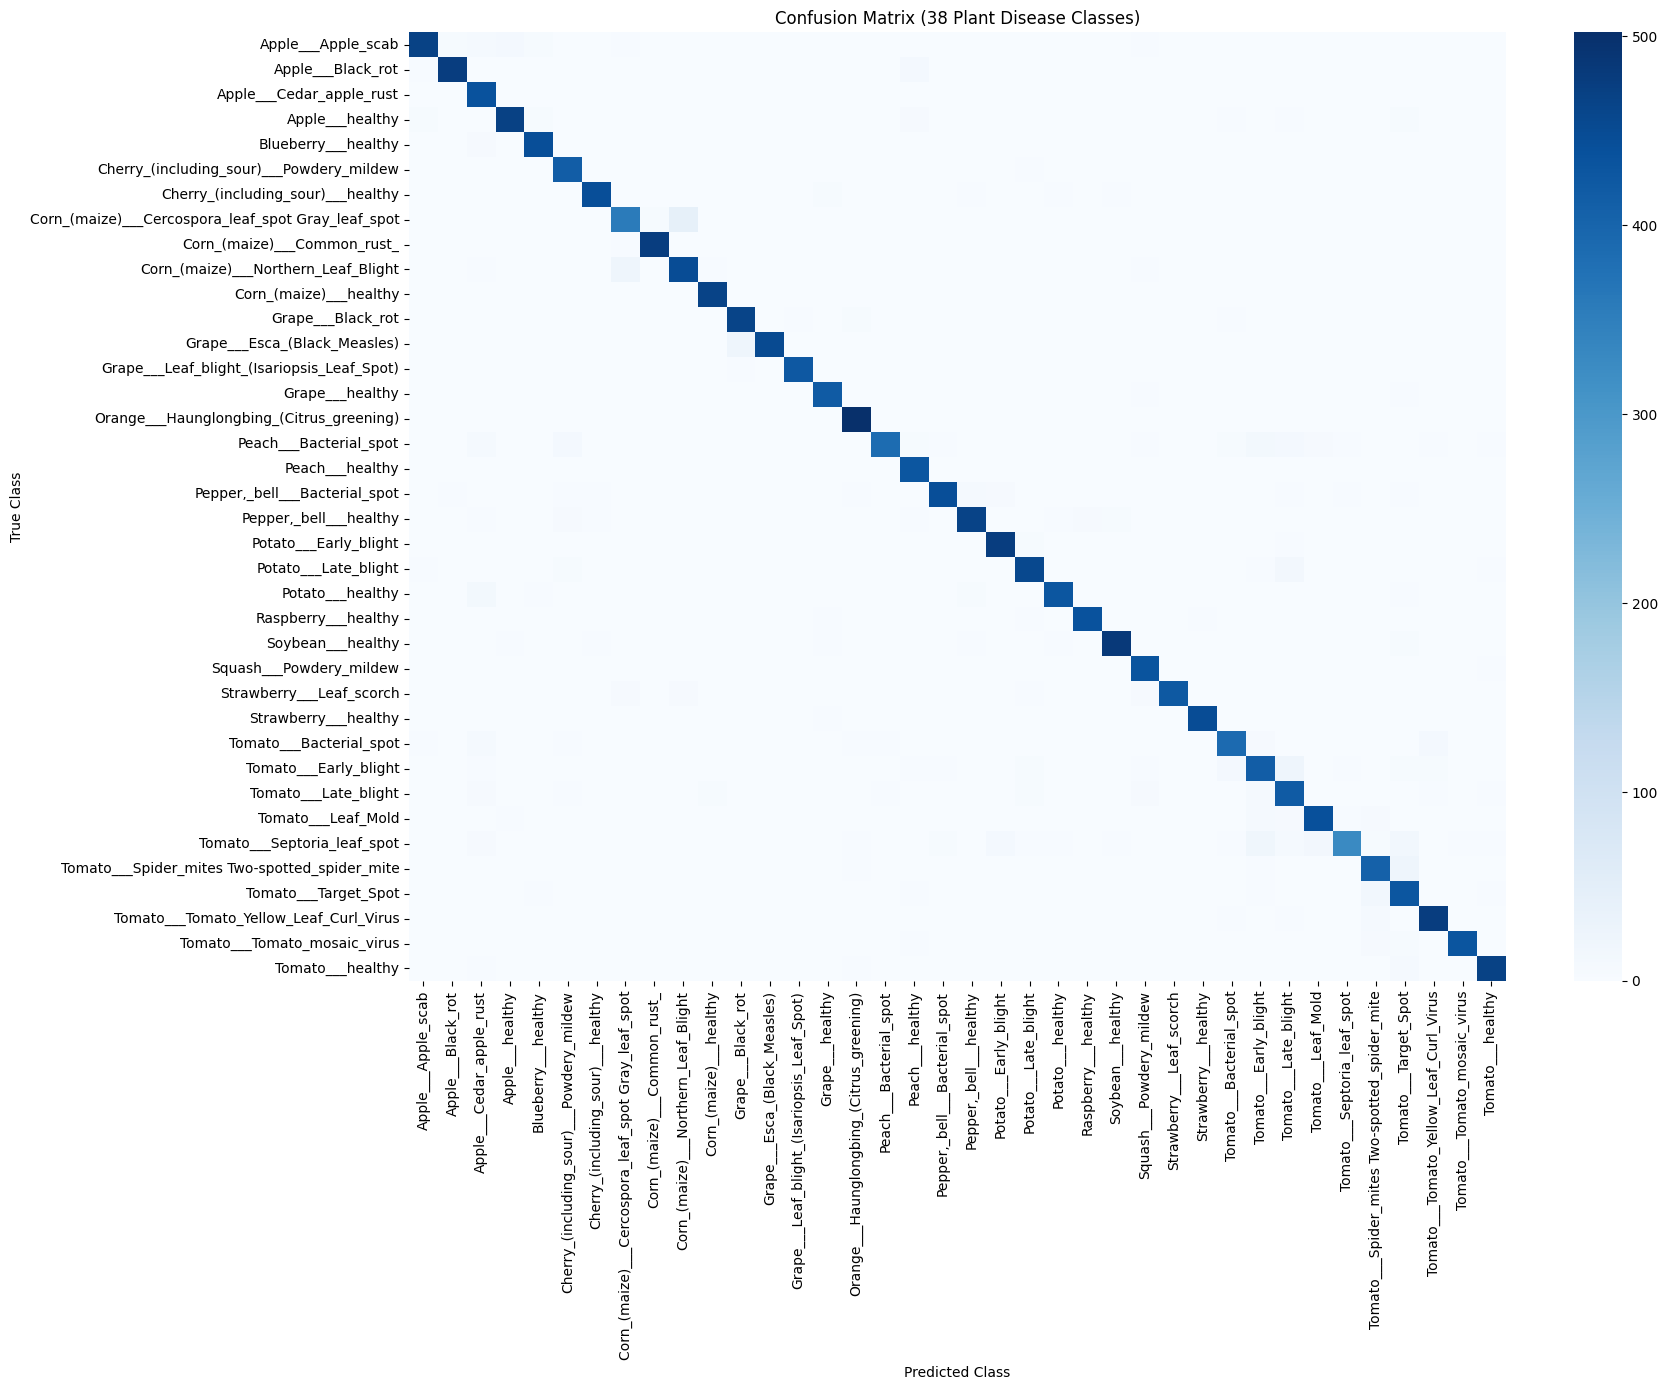

In [ ]:
# Visualizing the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('Confusion Matrix (38 Plant Disease Classes)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Found 33 images in the test folder.


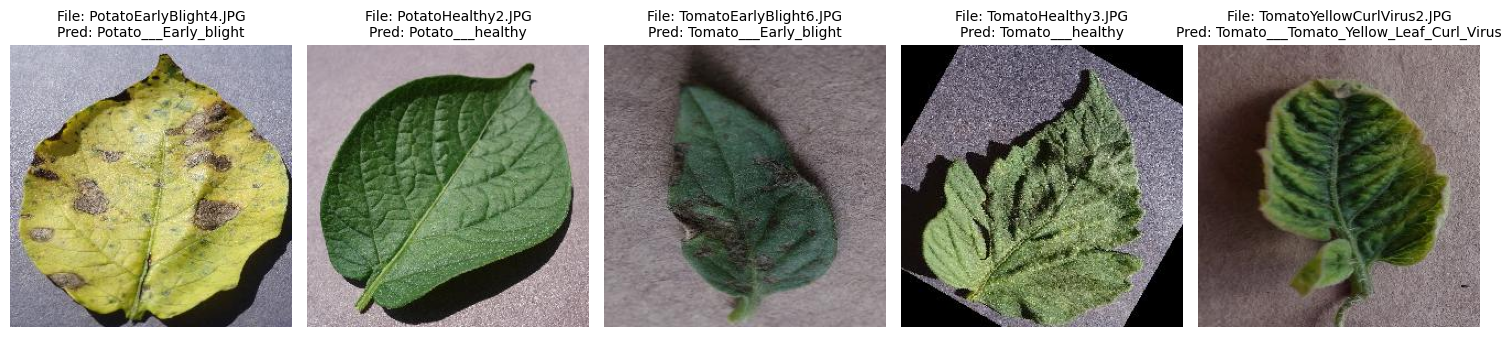

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = train_dataset.classes

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor() # Automatically scales pixel values to [0.0, 1.0]
])

baseline_model.eval()

valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
test_images = [f for f in os.listdir(test_dir) if f.endswith(valid_extensions)]

print(f"Found {len(test_images)} images in the test folder.")

# Predicts and displays the first 5 test images as a sample
num_to_show = min(5, len(test_images))
plt.figure(figsize=(15, 5))

for i in range(num_to_show):
    img_name = test_images[i]
    img_path = os.path.join(test_dir, img_name)

    # Open image using Pillow library
    raw_image = Image.open(img_path).convert('RGB')

    # Applies baseline preprocessing and adds required batch dimension
    input_tensor = test_transform(raw_image).unsqueeze(0) # Shapes it to [1, 3, 224, 224]
    input_tensor = input_tensor.to(device)

    # Forward pass through baseline CNN
    with torch.no_grad():
        outputs = baseline_model(input_tensor)
        _, predicted_idx = outputs.max(1)
        predicted_class = class_names[predicted_idx.item()]

    # Plots the result visually
    plt.subplot(1, num_to_show, i + 1)
    plt.imshow(raw_image)
    plt.title(f"File: {img_name}\nPred: {predicted_class}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


#Saving the model

In [ ]:
torch.save(baseline_model.state_dict(), '/content/drive/MyDrive/GUVI-DS-PRACTICE/datasets/Baseline_CNN_Weights.pth')
print('Baseline Model Weights Saved Successfully!')

Baseline Model Weights Saved Successfully!
